PyTorch version: 2.10.0+cu128
Device: cuda
eager       : 1.028 ms/iter
aot_eager   : 1.532 ms/iter


W0317 00:08:15.603000 5892 torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode


inductor    : 1.269 ms/iter
cudagraphs  : 1.040 ms/iter


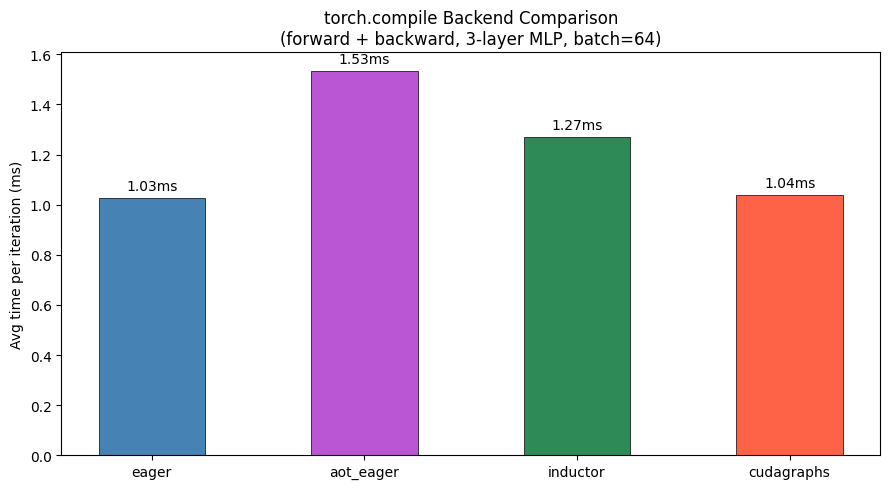

In [4]:
# Part 1: Comparing Backends (10 points)

import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
        )

    def forward(self, x):
        return self.net(x)

backends = ['eager', 'aot_eager', 'inductor', 'cudagraphs']
N_RUNS = 100
BATCH_SIZE = 64
backend_times = {}

for backend in backends:
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

    if backend == 'eager':
        compiled_model = model
    else:
        compiled_model = torch.compile(model, backend=backend)

    x = torch.randn(BATCH_SIZE, 512, device=device)

    # Warmup — triggers compilation for compiled backends
    for _ in range(5):
        optimizer.zero_grad()
        out = compiled_model(x)
        loss = out.mean()
        loss.backward()
        optimizer.step()

    torch.cuda.synchronize()

    # Timed runs
    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        optimizer.zero_grad()
        out = compiled_model(x)
        loss = out.mean()
        loss.backward()
        optimizer.step()

    torch.cuda.synchronize()

    avg_ms = (time.perf_counter() - t0) / N_RUNS * 1e3
    backend_times[backend] = avg_ms
    print(f'{backend:12s}: {avg_ms:.3f} ms/iter')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'mediumorchid', 'seagreen', 'tomato']
names = list(backend_times.keys())
times = list(backend_times.values())

bars = ax.bar(names, times, color=colors, edgecolor='black', linewidth=0.5, width=0.5)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{t:.2f}ms', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Avg time per iteration (ms)')
ax.set_title('torch.compile Backend Comparison\n(forward + backward, 3-layer MLP, batch=64)')
plt.tight_layout()
plt.savefig('part1_backends.png', dpi=150)
plt.show()

In [ ]:
#  Explain: Why do different backends have different performance? What
# are the tradeoffs?

# **Results:**
# - eager:      1.028 ms/iter
# - aot_eager:  1.532 ms/iter
# - inductor:   1.269 ms/iter
# - cudagraphs: 1.040 ms/iter

# Eager runs operations immediately with no compilation overhead. Making it the fastest for small models. Where compilation costs outweigh runtime savings.
# AOT Eager traces the forward adn backward graphs ahead of time but performs no kernel optimization. It pays the tracing overhead without any execution speedup, making it the slowest operation here.
# Inductor runs the full compilation pipeline. CoLab isn't able to fully leverage aggressive optimizations. Inductor typically wins by the a significant margin.
# CudaGraphs captures the entire CUDA op sequence as a static graph and replays it with a single driver call. Minimize kernel launch overhead.

# Since the model is quite small,  eager wins out on being the fastest here. With a larger model that would not be the case.

In [5]:
# Part 2: Debugging Compilation Failures (10 points)

# --- BROKEN ---
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

# --- FIXED ---
def problem1_fixed(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

x = torch.randn(4, device=device)

# Test both
compiled_broken = torch.compile(problem1)
compiled_fixed  = torch.compile(problem1_fixed)

print('Broken output:', compiled_broken(x))
print('Fixed output: ', compiled_fixed(x))
print('Match:', torch.allclose(problem1(x), problem1_fixed(x)))

# Explain what Dynamo sees
print('\n--- Dynamo explain (broken) ---')
explanation = torch._dynamo.explain(problem1)(x)
print(explanation)

Broken output: tensor([ 0.1497,  0.5672, -1.1167, -0.1096], device='cuda:0')
Fixed output:  tensor([ 0.1497,  0.5672, -1.1167, -0.1096], device='cuda:0')
Match: True

--- Dynamo explain (broken) ---
Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_5892/3078612605.py, line 5 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function truediv>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: Non

In [6]:
# --- BROKEN ---
def problem2(x):
    d = {}
    d['key'] = x
    return d['key'] * 2

# --- FIXED ---
def problem2_fixed(x):
    return x * 2

x = torch.randn(4, device=device)

compiled_broken = torch.compile(problem2)
compiled_fixed  = torch.compile(problem2_fixed)

print('Broken output:', compiled_broken(x))
print('Fixed output: ', compiled_fixed(x))
print('Match:', torch.allclose(problem2(x), problem2_fixed(x)))

print('\n--- Dynamo explain (broken) ---')
explanation = torch._dynamo.explain(problem2)(x)
print(explanation)

Broken output: tensor([-1.5310,  2.9746,  0.6986,  0.6846], device='cuda:0')
Fixed output:  tensor([-1.5310,  2.9746,  0.6986,  0.6846], device='cuda:0')
Match: True

--- Dynamo explain (broken) ---
Graph Count: 1
Graph Break Count: 0
Op Count: 1
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils

In [7]:
# --- BROKEN ---
def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

# --- FIXED ---
def problem3_fixed(x):
    powers = torch.stack([x ** i for i in range(10)])
    return powers.sum()

x = torch.randn(4, device=device)

compiled_broken = torch.compile(problem3)
compiled_fixed  = torch.compile(problem3_fixed)

print('Broken output:', compiled_broken(x))
print('Fixed output: ', compiled_fixed(x))
print('Match:', torch.allclose(
    torch.tensor(float(problem3(x))),
    problem3_fixed(x)
))

print('\n--- Dynamo explain (broken) ---')
explanation = torch._dynamo.explain(problem3)(x)
print(explanation)

print('\n--- Dynamo explain (fixed) ---')
explanation_fixed = torch._dynamo.explain(problem3_fixed)(x)
print(explanation_fixed)

Broken output: tensor(-12.4546, device='cuda:0')
Fixed output:  tensor(-12.4546, device='cuda:0')
Match: True

--- Dynamo explain (broken) ---
Graph Count: 1
Graph Break Count: 0
Op Count: 20
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function pow>
    <built-in function add>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
 

In [8]:
# Part 3: Graph Capture and Inspection (15 points)

python_list = []  # external mutable state

def mixed_fn(x, W1, W2):
    # Two matrix multiplications
    h  = torch.mm(x, W1)
    h2 = torch.mm(h, W2)

    # ReLU activation
    h2 = torch.relu(h2)

    # Residual connection
    h2 = h2 + torch.mm(x, W2)

    # Layer normalization
    h2 = F.layer_norm(h2, h2.shape[-1:])

    # Python side effects — these should NOT be captured
    print('Hello from mixed_fn')
    python_list.append(h2.shape)

    return h2

x  = torch.randn(4, 8, device=device)
W1 = torch.randn(8, 8, device=device)
W2 = torch.randn(8, 8, device=device)

# fullgraph=True errors if there are any graph breaks
try:
    compiled_full = torch.compile(mixed_fn, fullgraph=True)
    out = compiled_full(x, W1, W2)
    print('fullgraph=True succeeded')
except Exception as e:
    print(f'fullgraph=True failed (expected): {type(e).__name__}')
    print(f'Reason: {e}')

compiled_partial = torch.compile(mixed_fn)
out = compiled_partial(x, W1, W2)
print('Output shape:', out.shape)
print('python_list contents:', python_list)

print('\n--- Dynamo explain ---')
explanation = torch._dynamo.explain(mixed_fn)(x, W1, W2)
print(explanation)

from torch._functorch.aot_autograd import make_fx

# Clean version with no side effects for make_fx
def clean_fn(x, W1, W2):
    h  = torch.mm(x, W1)
    h2 = torch.mm(h, W2)
    h2 = torch.relu(h2)
    h2 = h2 + torch.mm(x, W2)
    h2 = F.layer_norm(h2, h2.shape[-1:])
    return h2

fx_graph = make_fx(clean_fn)(x, W1, W2)

print('=== FX Graph IR ===')
fx_graph.print_readable()

print('\n=== Graph Nodes ===')
for node in fx_graph.graph.nodes:
    print(f'  op={node.op:12s}  name={node.name:30s}  target={str(node.target)}')

fullgraph=True failed (expected): Unsupported
Reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html

from user code:
   File "/tmp/ipykernel_5892/2553727613.py", line 20, in mixed_fn
    print('Hello from mixed_fn')

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bu

In [ ]:
# ## Computation Graph
#
#     x ──────────────────────────────────┐
#     │                                    │
#     ▼                                    ▼
#   mm(x, W1)                         mm(x, W2)  ← residual branch
#     │                                    │
#     ▼                                    │
#   mm(h, W2)                             │
#     │                                    │
#     ▼                                    │
#   relu(h2)                              │
#     │                                    │
#     └──────────── add ──────────────────┘
#                    │
#                    ▼
#              layer_norm
#                    │
#                    ▼
#                 output
#
# [ print() and python_list.append() — NOT in graph ]

In [ ]:
## Part 3 Analysis

# **Which operations appear in the graph?**
# All pure tensor operations are captured (6 ops total):
# - torch.mm (×3 — two matmuls + one for the residual branch)
# - torch.relu
# - torch.add (residual connection)
# - native_layer_norm (decomposed internally into mean, variance, normalize)

# **Which operations are NOT captured?**
# - print('Hello from mixed_fn') — Python side effect with no tensor output.
#  fullgraph=True explicitly failed with: "Dynamo does not know how to trace
#  builtin operator print". Without fullgraph, Dynamo handles it by executing
#  the print in Python and continuing compilation after.
# - python_list.append(h2.shape) — External Python list mutation. Not a tensor
#  op so it never enters the graph. It executed once during tracing
#  (python_list contents: [torch.Size([4, 8])]) but will not re-execute
#  on subsequent compiled calls.

# **What happens to the print statement?**
# With fullgraph=True it causes a hard failure. Without fullgraph, Dynamo
# executes it eagerly during the traced call but does not include it in the
# compiled graph — it fires once at trace time and is then effectively gone.

# **What happens to the list modification?**
# Same story — executed once during tracing, never recorded in the graph.
# Subsequent compiled calls do not re-append to python_list. This is a
# common silent bug in compiled PyTorch code.